In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn[1].csv')
print("shape",df.shape)
df.head()


shape (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data Cleaning

# Fix TotalCharges - convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove 11 blank rows
df = df.dropna(subset=['TotalCharges'])

# Fix SeniorCitizen - convert 0/1 to No/Yes
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

# Convert Churn to 1/0 for calculations
df['Churn_Binary'] = df['Churn'].map({'Yes':1, 'No':0})

# Verify cleaning
print("Rows after cleaning:", df.shape[0])
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn value counts:")
print(df['Churn'].value_counts())

Rows after cleaning: 7032

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Binary        0
dtype: int64

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [4]:
# EDA - Finding Churn Patterns

# 1. Overall Churn Rate
churn_rate = df['Churn_Binary'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# 2. Churn by Contract Type
print("\nChurn Rate by Contract Type:")
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
print(contract_churn.round(2))

# 3. Churn by Tenure Group
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-12 Months','13-24 Months',
                                     '25-48 Months','49+ Months'])
print("\nChurn Rate by Tenure Group:")
tenure_churn = df.groupby('Tenure_Group')['Churn_Binary'].mean() * 100
print(tenure_churn.round(2))

# 4. Churn by Monthly Charges Group
df['Charges_Group'] = pd.cut(df['MonthlyCharges'],
                              bins=[0,30,60,90,120],
                              labels=['Low (0-30)','Medium (31-60)',
                                      'High (61-90)','Very High (90+)'])
print("\nChurn Rate by Monthly Charges:")
charges_churn = df.groupby('Charges_Group')['Churn_Binary'].mean() * 100
print(charges_churn.round(2))

Overall Churn Rate: 26.58%

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn_Binary, dtype: float64

Churn Rate by Tenure Group:
Tenure_Group
0-12 Months     47.68
13-24 Months    28.71
25-48 Months    20.39
49+ Months       9.51
Name: Churn_Binary, dtype: float64

Churn Rate by Monthly Charges:
Charges_Group
Low (0-30)          9.84
Medium (31-60)     25.97
High (61-90)       33.95
Very High (90+)    32.78
Name: Churn_Binary, dtype: float64


/tmp/ipykernel_9006/3517477716.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('Tenure_Group')['Churn_Binary'].mean() * 100
/tmp/ipykernel_9006/3517477716.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charges_churn = df.groupby('Charges_Group')['Churn_Binary'].mean() * 100


/tmp/ipykernel_9006/2318553246.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_data = df.groupby('Tenure_Group')['Churn_Binary'].mean() * 100
/tmp/ipykernel_9006/2318553246.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charges_data = df.groupby('Charges_Group')['Churn_Binary'].mean() * 100


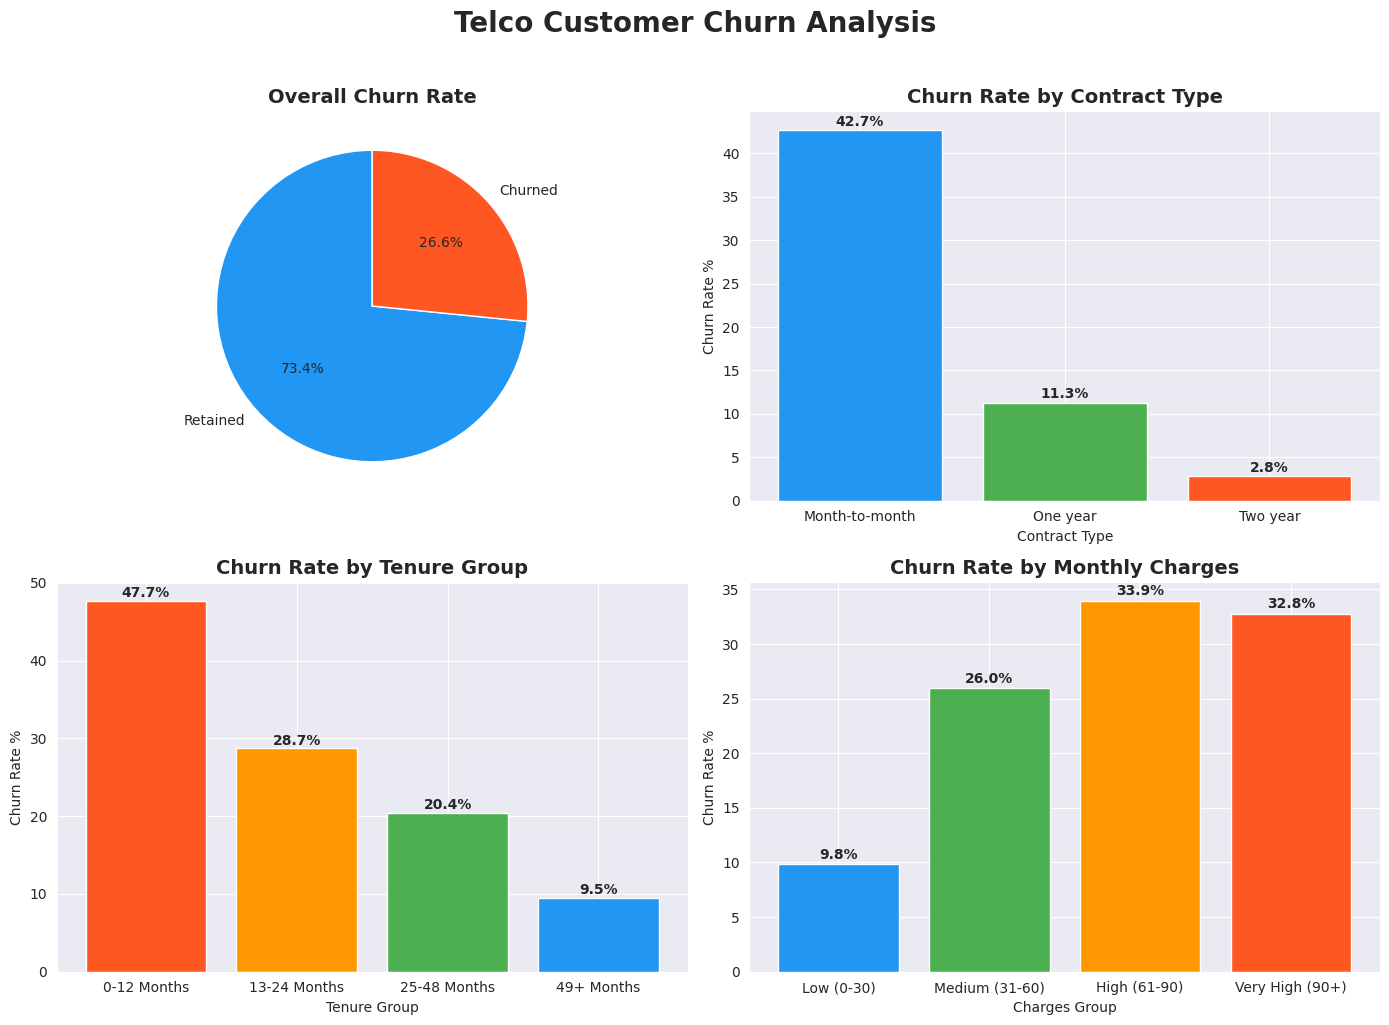

Chart saved successfully!


In [5]:
# Set style for all charts
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telco Customer Churn Analysis', fontsize=20, fontweight='bold', y=1.02)

# Chart 1 - Overall Churn Rate (Pie Chart)
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts,
              labels=['Retained', 'Churned'],
              colors=['#2196F3', '#FF5722'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,0].set_title('Overall Churn Rate', fontsize=14, fontweight='bold')

# Chart 2 - Churn by Contract Type
contract_data = df.groupby('Contract')['Churn_Binary'].mean() * 100
axes[0,1].bar(contract_data.index,
              contract_data.values,
              color=['#2196F3', '#4CAF50', '#FF5722'])
axes[0,1].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate %')
axes[0,1].set_xlabel('Contract Type')
for i, v in enumerate(contract_data.values):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 3 - Churn by Tenure Group
tenure_data = df.groupby('Tenure_Group')['Churn_Binary'].mean() * 100
axes[1,0].bar(tenure_data.index,
              tenure_data.values,
              color=['#FF5722', '#FF9800', '#4CAF50', '#2196F3'])
axes[1,0].set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Churn Rate %')
axes[1,0].set_xlabel('Tenure Group')
for i, v in enumerate(tenure_data.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 4 - Churn by Monthly Charges
charges_data = df.groupby('Charges_Group')['Churn_Binary'].mean() * 100
axes[1,1].bar(charges_data.index,
              charges_data.values,
              color=['#2196F3', '#4CAF50', '#FF9800', '#FF5722'])
axes[1,1].set_title('Churn Rate by Monthly Charges', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Churn Rate %')
axes[1,1].set_xlabel('Charges Group')
for i, v in enumerate(charges_data.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")

In [6]:
# Final Business Summary Report
print("=" * 55)
print("   TELCO CUSTOMER CHURN ANALYSIS - SUMMARY REPORT")
print("=" * 55)

print(f"\n DATASET INFO")
print(f"   Total Customers     : {len(df):,}")
print(f"   Total Columns       : {df.shape[1]}")

print(f"\n KEY FINDINGS")
print(f"   Overall Churn Rate  : {df['Churn_Binary'].mean()*100:.1f}%")
print(f"   Total Churned       : {df['Churn_Binary'].sum():,} customers")
print(f"   Total Retained      : {(df['Churn_Binary']==0).sum():,} customers")

print(f"\n CHURN BY CONTRACT TYPE")
for contract, rate in contract_data.items():
    print(f"   {contract:<20}: {rate:.1f}%")

print(f"\n CHURN BY TENURE GROUP")
for tenure, rate in tenure_data.items():
    print(f"   {tenure:<20}: {rate:.1f}%")

print(f"\n CHURN BY MONTHLY CHARGES")
for charge, rate in charges_data.items():
    print(f"   {charge:<20}: {rate:.1f}%")

print(f"\n BUSINESS RECOMMENDATIONS")
print(f"   1. Convert month-to-month customers to annual plans")
print(f"      - Reduces churn from 42.7% to 2.8%")
print(f"   2. Focus retention efforts on 0-12 month customers")
print(f"      - New customers churn 5x more than loyal ones")
print(f"   3. Offer discounts to high paying customers (60$+)")
print(f"      - High charges increase churn risk to 33.9%")

print("\n" + "=" * 55)
print("   Analysis Complete!")
print("=" * 55)

   TELCO CUSTOMER CHURN ANALYSIS - SUMMARY REPORT

 DATASET INFO
   Total Customers     : 7,032
   Total Columns       : 24

 KEY FINDINGS
   Overall Churn Rate  : 26.6%
   Total Churned       : 1,869 customers
   Total Retained      : 5,163 customers

 CHURN BY CONTRACT TYPE
   Month-to-month      : 42.7%
   One year            : 11.3%
   Two year            : 2.8%

 CHURN BY TENURE GROUP
   0-12 Months         : 47.7%
   13-24 Months        : 28.7%
   25-48 Months        : 20.4%
   49+ Months          : 9.5%

 CHURN BY MONTHLY CHARGES
   Low (0-30)          : 9.8%
   Medium (31-60)      : 26.0%
   High (61-90)        : 33.9%
   Very High (90+)     : 32.8%

 BUSINESS RECOMMENDATIONS
   1. Convert month-to-month customers to annual plans
      - Reduces churn from 42.7% to 2.8%
   2. Focus retention efforts on 0-12 month customers
      - New customers churn 5x more than loyal ones
   3. Offer discounts to high paying customers (60$+)
      - High charges increase churn risk to 33.9%



In [7]:
# Step 1 - Prepare data for ML
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop columns not needed for prediction
df_ml = df.drop(['customerID', 'Churn', 'Tenure_Group', 'Charges_Group'], axis=1)

# Convert all text columns to numbers
# ML models only understand numbers not text
le = LabelEncoder()
text_columns = df_ml.select_dtypes(include=['object']).columns

for col in text_columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# Define X (input features) and y (target)
X = df_ml.drop('Churn_Binary', axis=1)
y = df_ml['Churn_Binary']

# Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size :", X_test.shape)
print("Features used     :", X_train.shape[1])

Training data size: (5625, 19)
Testing data size : (1407, 19)
Features used     : 19


In [8]:
# Step 2 - Build ML Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Model 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Compare both models
print("=" * 40)
print("      MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression : {lr_accuracy*100:.2f}%")
print(f"Random Forest       : {rf_accuracy*100:.2f}%")
print("=" * 40)

# Detailed report for best model
print("\nDetailed Report - Random Forest:")
print(classification_report(y_test, rf_predictions,
      target_names=['Stayed', 'Churned']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


      MODEL COMPARISON
Logistic Regression : 78.54%
Random Forest       : 79.25%

Detailed Report - Random Forest:
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



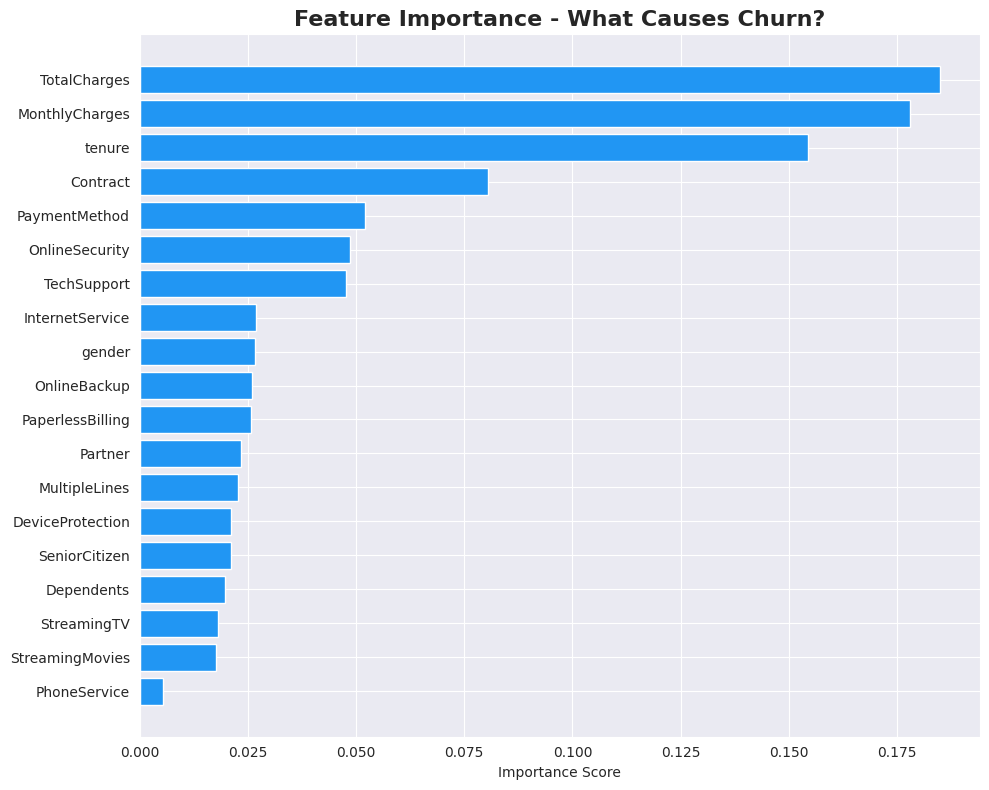


Top 5 Factors Causing Churn:
TotalCharges             : 0.1850
MonthlyCharges           : 0.1780
tenure                   : 0.1545
Contract                 : 0.0806
PaymentMethod            : 0.0520


In [9]:
# Step 3 - Feature Importance
# Which factors cause churn the most?

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    'Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color='#2196F3')
plt.title('Feature Importance - What Causes Churn?',
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Print top 5 factors
print("\nTop 5 Factors Causing Churn:")
print("=" * 40)
top5 = feature_importance.sort_values('Importance', ascending=False).head()
for i, row in top5.iterrows():
    print(f"{row['Feature']:<25}: {row['Importance']:.4f}")

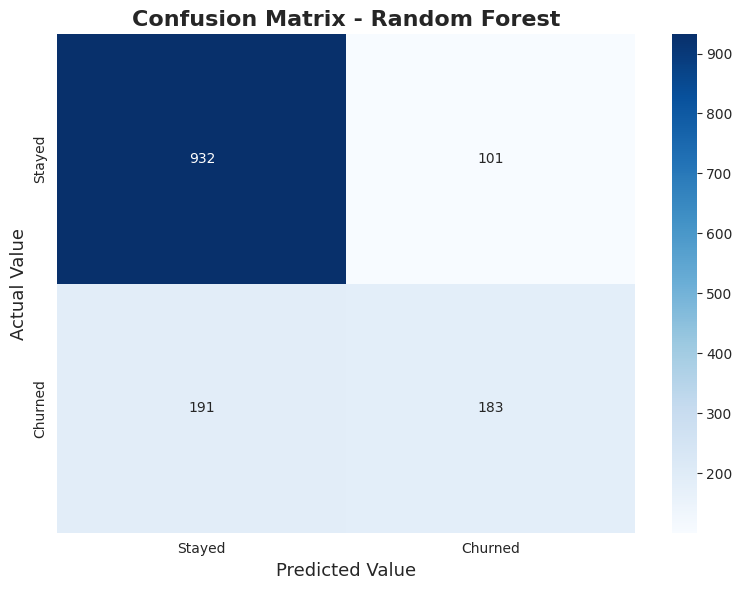


Confusion Matrix Explanation:
Correctly predicted Stayed  (TN): 932
Wrongly predicted as Churned(FP): 101
Wrongly predicted as Stayed (FN): 191
Correctly predicted Churned (TP): 183
Total correct predictions: 1115
Total wrong predictions  : 292


In [10]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Confusion Matrix - Random Forest',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual Value', fontsize=13)
plt.xlabel('Predicted Value', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Explain the numbers
print("\nConfusion Matrix Explanation:")
print("=" * 45)
print(f"Correctly predicted Stayed  (TN): {cm[0][0]}")
print(f"Wrongly predicted as Churned(FP): {cm[0][1]}")
print(f"Wrongly predicted as Stayed (FN): {cm[1][0]}")
print(f"Correctly predicted Churned (TP): {cm[1][1]}")
print("=" * 45)
print(f"Total correct predictions: {cm[0][0] + cm[1][1]}")
print(f"Total wrong predictions  : {cm[0][1] + cm[1][0]}")

In [11]:
# Predict churn for a brand new customer
import numpy as np

# Create a new customer profile
# This customer is HIGH RISK based on our analysis
new_customer = pd.DataFrame({
    'gender': [1],              # Male
    'SeniorCitizen': [0],       # Not senior
    'Partner': [0],             # No partner
    'Dependents': [0],          # No dependents
    'tenure': [2],              # Only 2 months old!
    'PhoneService': [1],        # Has phone
    'MultipleLines': [1],       # Has multiple lines
    'InternetService': [1],     # Fiber optic
    'OnlineSecurity': [0],      # No security
    'OnlineBackup': [0],        # No backup
    'DeviceProtection': [0],    # No protection
    'TechSupport': [0],         # No tech support
    'StreamingTV': [1],         # Has streaming TV
    'StreamingMovies': [1],     # Has streaming movies
    'Contract': [0],            # Month to month!
    'PaperlessBilling': [1],    # Paperless billing
    'PaymentMethod': [2],       # Electronic check
    'MonthlyCharges': [85.0],   # High charges!
    'TotalCharges': [170.0]     # Low total (new customer)
})

# Make prediction
prediction = rf_model.predict(new_customer)
probability = rf_model.predict_proba(new_customer)

print("=" * 45)
print("     NEW CUSTOMER CHURN PREDICTION")
print("=" * 45)
print(f"Tenure          : 2 months")
print(f"Contract        : Month-to-month")
print(f"Monthly Charges : $85")
print(f"Prediction      : {'WILL CHURN ⚠️' if prediction[0]==1 else 'WILL STAY ✅'}")
print(f"Churn Risk      : {probability[0][1]*100:.1f}%")
print(f"Stay  Chance    : {probability[0][0]*100:.1f}%")
print("=" * 45)
if prediction[0] == 1:
    print("RECOMMENDATION: Offer discount or annual plan")
    print("immediately to retain this customer!")
else:
    print("RECOMMENDATION: Customer is loyal - no")
    print("immediate retention action needed!")

     NEW CUSTOMER CHURN PREDICTION
Tenure          : 2 months
Contract        : Month-to-month
Monthly Charges : $85
Prediction      : WILL CHURN ⚠️
Churn Risk      : 61.0%
Stay  Chance    : 39.0%
RECOMMENDATION: Offer discount or annual plan
immediately to retain this customer!
